In [2]:
import torch
import torchvision
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A
import cv2

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("All imports successful!")

PyTorch: 2.12.0+cpu
Torchvision: 0.27.0+cpu
All imports successful!


In [3]:
import os
import json
import shutil
import random
from pathlib import Path
from collections import defaultdict
import numpy as np
import matplotlib.image as mpimg
from PIL import Image

BASE_DIR = Path(r"C:\Users\ishas\OneDrive\Desktop\ML\Ecolens")


RAW_DIR       = BASE_DIR / "data" / "raw"
TRASHNET_DIR  = RAW_DIR / "trashnet"
KAGGLE_DIR    = RAW_DIR / "kaggle"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
TRAIN_DIR     = BASE_DIR / "data" / "train"
VAL_DIR       = BASE_DIR / "data" / "val"
TEST_DIR      = BASE_DIR / "data" / "test"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR exists  :", BASE_DIR.exists())
print("TrashNet found   :", TRASHNET_DIR.exists())
print("Kaggle found     :", KAGGLE_DIR.exists())
print()
print("TrashNet classes :", sorted([f.name for f in TRASHNET_DIR.iterdir() if f.is_dir()]))
print("Kaggle classes   :", sorted([f.name for f in KAGGLE_DIR.iterdir() if f.is_dir()]))

BASE_DIR exists  : True
TrashNet found   : True
Kaggle found     : True

TrashNet classes : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Kaggle classes   : ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


In [4]:
CLASS_TAXONOMY = {
    "0": "recyclable_plastic",
    "1": "glass",
    "2": "metal",
    "3": "paper_cardboard",
    "4": "organic_biodegradable",
    "5": "hazardous",
    "6": "non_recyclable_trash"
}

CLASS_MAPPING = {
    # TrashNet classes
    "plastic"     : "recyclable_plastic",
    "glass"       : "glass",
    "metal"       : "metal",
    "paper"       : "paper_cardboard",
    "cardboard"   : "paper_cardboard",
    "trash"       : "non_recyclable_trash",
    # Kaggle 12-class
    "battery"     : "hazardous",
    "biological"  : "organic_biodegradable",
    "brown-glass" : "glass",
    "green-glass" : "glass",
    "white-glass" : "glass",
    "clothes"     : "non_recyclable_trash",
    "shoes"       : "non_recyclable_trash",
}

with open(BASE_DIR / "data" / "class_labels.json", "w") as f:
    json.dump(CLASS_TAXONOMY, f, indent=2)

print("7-class taxonomy saved to class_labels.json")
print("-" * 40)
for k, v in CLASS_TAXONOMY.items():
    print(f"  Class {k} → {v}")
print(f"\nRaw classes being mapped: {len(CLASS_MAPPING)}")

7-class taxonomy saved to class_labels.json
----------------------------------------
  Class 0 → recyclable_plastic
  Class 1 → glass
  Class 2 → metal
  Class 3 → paper_cardboard
  Class 4 → organic_biodegradable
  Class 5 → hazardous
  Class 6 → non_recyclable_trash

Raw classes being mapped: 13


In [5]:
def count_images(dataset_dir, dataset_name):
    counts = {}
    total  = 0
    valid_ext = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

    for class_folder in sorted(dataset_dir.iterdir()):
        if class_folder.is_dir():
            images = [f for f in class_folder.iterdir()
                      if f.suffix in valid_ext]
            counts[class_folder.name] = len(images)
            total += len(images)

    print(f"\n{dataset_name} — {total} total images")
    print("-" * 45)
    for cls, cnt in sorted(counts.items()):
        bar = "█" * (cnt // 50)
        print(f"  {cls:<20} {cnt:>5}  {bar}")

    return counts

trashnet_counts = count_images(TRASHNET_DIR, "TrashNet")
kaggle_counts   = count_images(KAGGLE_DIR,   "Kaggle 12-class")

print(f"\nCombined raw total: "
      f"{sum(trashnet_counts.values()) + sum(kaggle_counts.values())} images")


TrashNet — 2527 total images
---------------------------------------------
  cardboard              403  ████████
  glass                  501  ██████████
  metal                  410  ████████
  paper                  594  ███████████
  plastic                482  █████████
  trash                  137  ██

Kaggle 12-class — 15515 total images
---------------------------------------------
  battery                945  ██████████████████
  biological             985  ███████████████████
  brown-glass            607  ████████████
  cardboard              891  █████████████████
  clothes               5325  ██████████████████████████████████████████████████████████████████████████████████████████████████████████
  green-glass            629  ████████████
  metal                  769  ███████████████
  paper                 1050  █████████████████████
  plastic                865  █████████████████
  shoes                 1977  ███████████████████████████████████████
  trash             

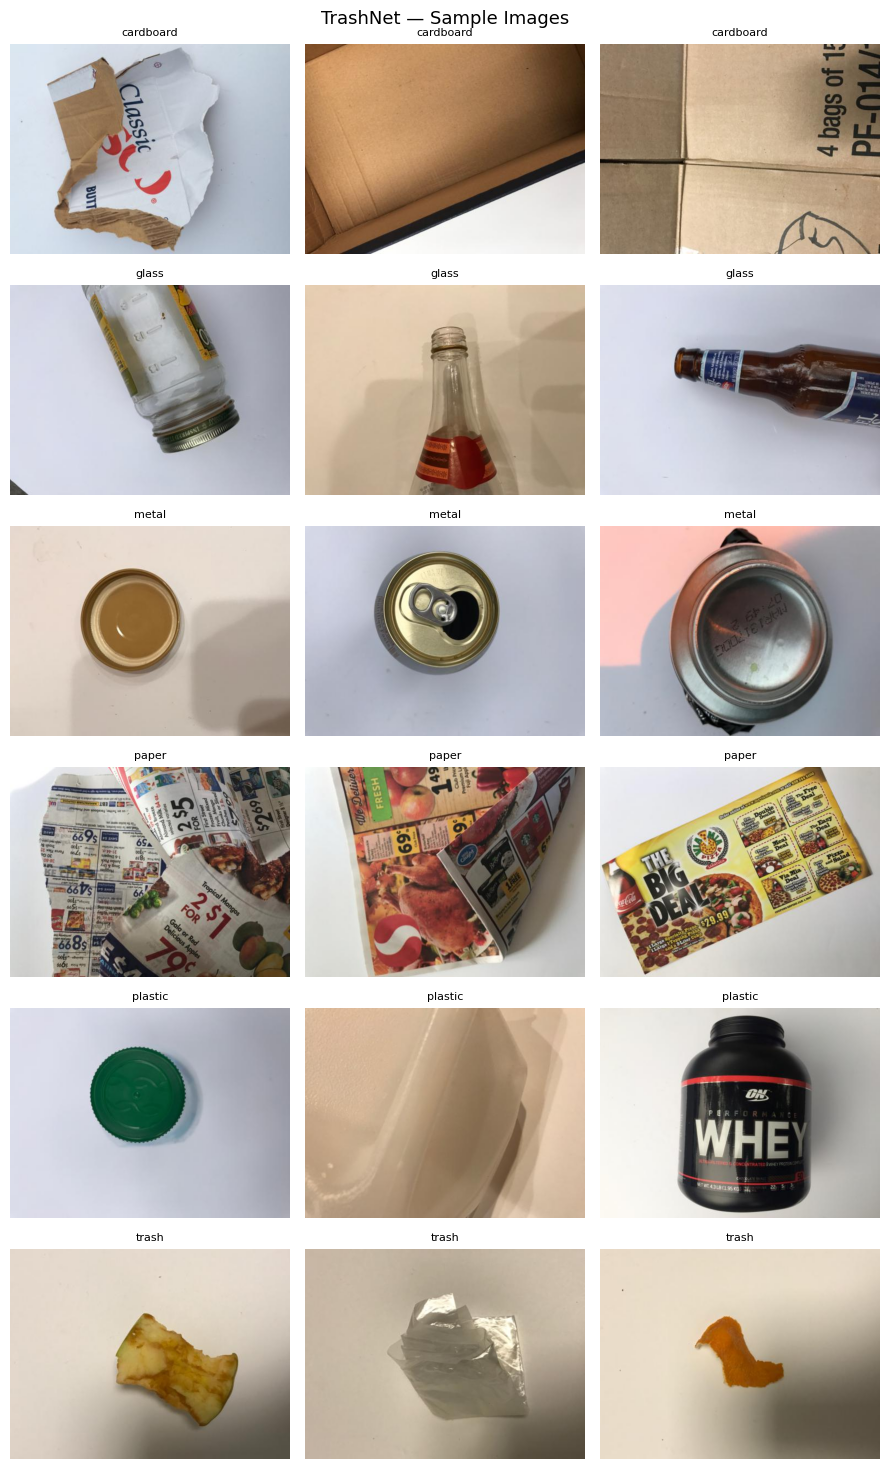

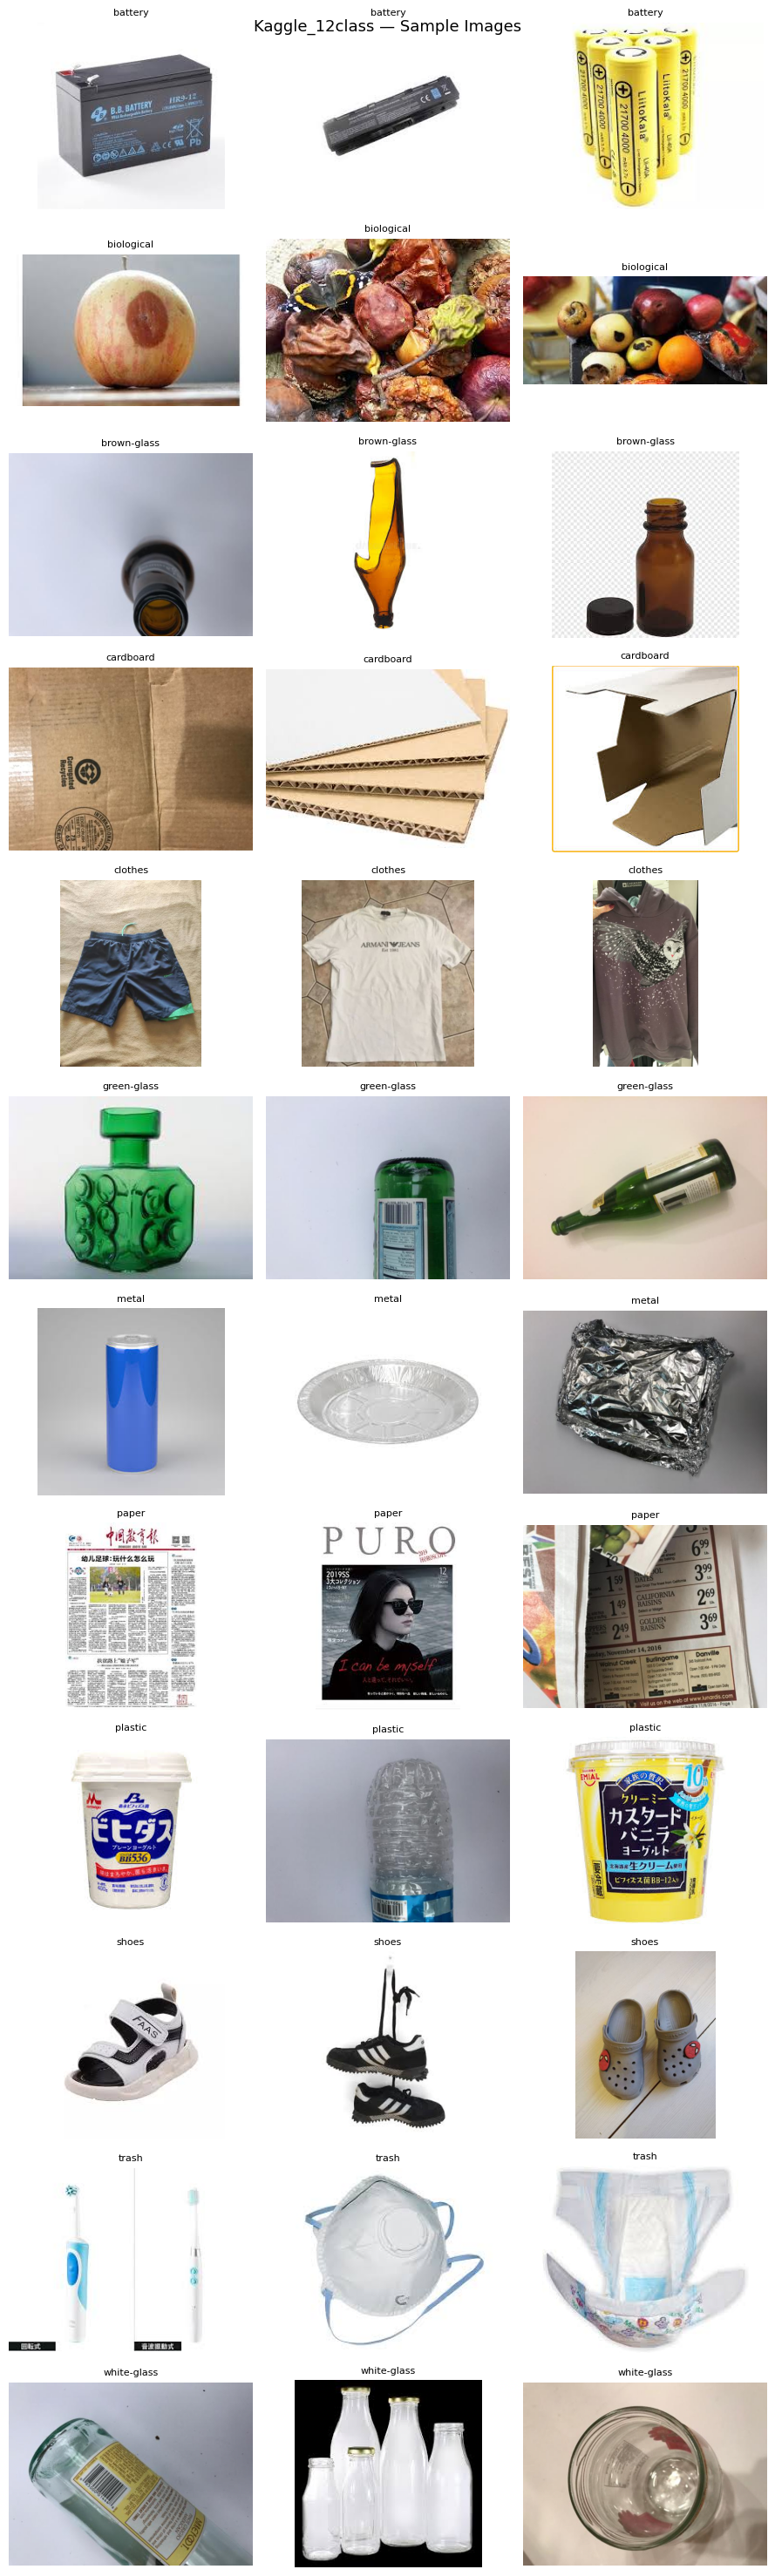

In [6]:
def show_samples(dataset_dir, dataset_name, samples_per_class=3):
    classes   = sorted([f for f in dataset_dir.iterdir() if f.is_dir()])
    n_classes = len(classes)
    valid_ext = {'.jpg','.jpeg','.png','.JPG','.JPEG','.PNG'}

    fig, axes = plt.subplots(
        n_classes, samples_per_class,
        figsize=(samples_per_class * 3, n_classes * 2.5)
    )
    fig.suptitle(f"{dataset_name} — Sample Images", fontsize=13)

    for row, class_folder in enumerate(classes):
        images  = [f for f in class_folder.iterdir() if f.suffix in valid_ext]
        samples = random.sample(images, min(samples_per_class, len(images)))

        for col in range(samples_per_class):
            ax = axes[row][col] if n_classes > 1 else axes[col]
            if col < len(samples):
                img = mpimg.imread(str(samples[col]))
                ax.imshow(img)
                ax.set_title(class_folder.name, fontsize=8)
            ax.axis('off')

    plt.tight_layout()
    plt.savefig(BASE_DIR / "data" /
                f"{dataset_name.replace(' ','_')}_samples.png",
                dpi=80, bbox_inches='tight')
    plt.show()

show_samples(TRASHNET_DIR, "TrashNet")
show_samples(KAGGLE_DIR,   "Kaggle_12class")

In [13]:
def merge_datasets():
    valid_ext            = {'.jpg','.jpeg','.png','.JPG','.JPEG','.PNG'}
    MAX_PER_CLASS_SOURCE = 1500

    for class_name in CLASS_TAXONOMY.values():
        (PROCESSED_DIR / class_name).mkdir(parents=True, exist_ok=True)

    stats = defaultdict(int)

    for dataset_dir, prefix in [(TRASHNET_DIR,"trashnet"),(KAGGLE_DIR,"kaggle")]:
        for class_folder in sorted(dataset_dir.iterdir()):
            if not class_folder.is_dir():
                continue
            raw_class = class_folder.name.lower()
            if raw_class not in CLASS_MAPPING:
                continue
            unified_class = CLASS_MAPPING[raw_class]
            dest_folder   = PROCESSED_DIR / unified_class
            images = [f for f in class_folder.iterdir() if f.suffix in valid_ext]
            random.seed(42)
            random.shuffle(images)
            images = images[:MAX_PER_CLASS_SOURCE]
            for img_path in images:
                new_name  = f"{prefix}_{img_path.name}"
                dest_path = dest_folder / new_name
                if not dest_path.exists():
                    shutil.copy2(str(img_path), str(dest_path))
                    stats[unified_class] += 1

    print("MERGE COMPLETE — Images in processed/")
    print("=" * 45)
    total = 0
    for cls, cnt in sorted(stats.items()):
        print(f"  {cls:<25} {cnt:>5}")
        total += cnt

    # Count actual totals including previously copied files
    print("\nActual counts in processed/ (including previous runs):")
    grand_total = 0
    for cls_folder in sorted(PROCESSED_DIR.iterdir()):
        if cls_folder.is_dir():
            count = len(list(cls_folder.iterdir()))
            bar   = "█" * (count // 150)
            print(f"  {cls_folder.name:<25} {count:>5}  {bar}")
            grand_total += count
    print(f"\n  GRAND TOTAL: {grand_total} images across 7 classes")
    return stats

merge_stats = merge_datasets()

MERGE COMPLETE — Images in processed/

Actual counts in processed/ (including previous runs):
  glass                      2512  ████████████████
  hazardous                   945  ██████
  metal                      1179  ███████
  non_recyclable_trash       3834  █████████████████████████
  organic_biodegradable       985  ██████
  paper_cardboard            2938  ███████████████████
  recyclable_plastic         1347  ████████

  GRAND TOTAL: 13740 images across 7 classes


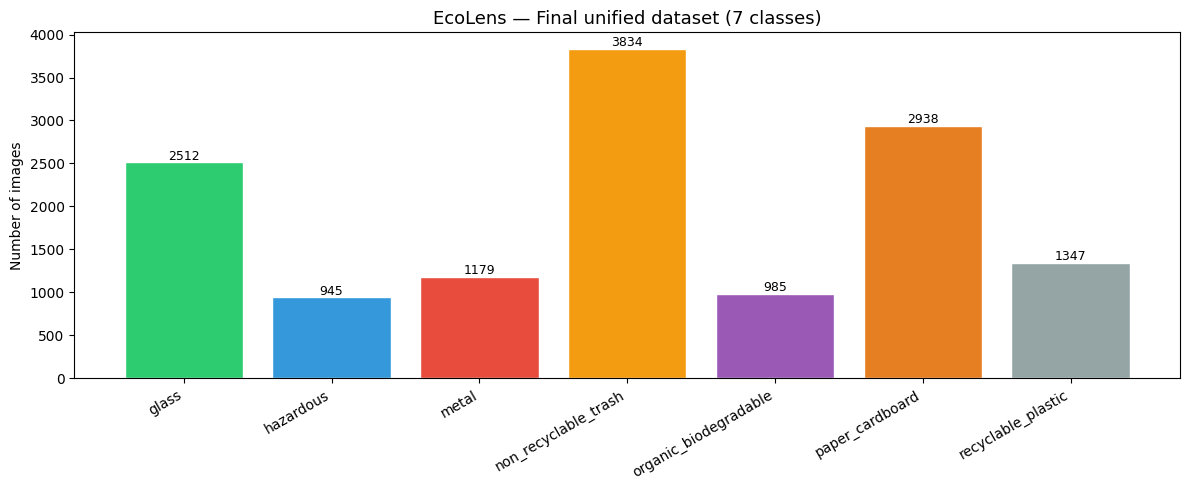

Largest class :  non_recyclable_trash — 3834
Smallest class:  hazardous — 945
Imbalance ratio: 4.1x


In [14]:
classes, counts = [], []
for cls_folder in sorted(PROCESSED_DIR.iterdir()):
    if cls_folder.is_dir():
        classes.append(cls_folder.name)
        counts.append(len(list(cls_folder.iterdir())))

colors = ['#2ecc71','#3498db','#e74c3c',
          '#f39c12','#9b59b6','#e67e22','#95a5a6']

plt.figure(figsize=(12, 5))
bars = plt.bar(classes, counts, color=colors, edgecolor='white')
plt.title("EcoLens — Final unified dataset (7 classes)", fontsize=13)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.ylabel("Number of images")

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 30,
             str(count), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(BASE_DIR / "data" / "class_distribution.png", dpi=120)
plt.show()

print(f"Largest class :  {classes[counts.index(max(counts))]} — {max(counts)}")
print(f"Smallest class:  {classes[counts.index(min(counts))]} — {min(counts)}")
print(f"Imbalance ratio: {max(counts)/min(counts):.1f}x")

In [15]:
def split_dataset(train_ratio=0.75, val_ratio=0.15, test_ratio=0.10):
    valid_ext = {'.jpg','.jpeg','.png','.JPG','.JPEG','.PNG'}

    for split in ['train', 'val', 'test']:
        for class_name in CLASS_TAXONOMY.values():
            (BASE_DIR / "data" / split / class_name).mkdir(parents=True, exist_ok=True)

    split_stats = defaultdict(lambda: defaultdict(int))

    for class_folder in sorted(PROCESSED_DIR.iterdir()):
        if not class_folder.is_dir():
            continue

        class_name = class_folder.name
        images     = [f for f in class_folder.iterdir() if f.suffix in valid_ext]

        random.seed(42)
        random.shuffle(images)

        n       = len(images)
        n_train = int(n * train_ratio)
        n_val   = int(n * val_ratio)

        splits = {
            'train': images[:n_train],
            'val'  : images[n_train : n_train + n_val],
            'test' : images[n_train + n_val:]
        }

        for split_name, split_images in splits.items():
            dest = BASE_DIR / "data" / split_name / class_name
            for img_path in split_images:
                dest_file = dest / img_path.name
                if not dest_file.exists():
                    shutil.copy2(str(img_path), str(dest_file))
                split_stats[split_name][class_name] += 1

    print("Train / Val / Test split complete!")
    print("=" * 58)
    print(f"  {'Class':<25} {'Train':>7} {'Val':>7} {'Test':>7}")
    print("-" * 58)
    for cls in sorted(CLASS_TAXONOMY.values()):
        tr = split_stats['train'][cls]
        va = split_stats['val'][cls]
        te = split_stats['test'][cls]
        print(f"  {cls:<25} {tr:>7} {va:>7} {te:>7}")
    print("-" * 58)
    t = sum(split_stats['train'].values())
    v = sum(split_stats['val'].values())
    e = sum(split_stats['test'].values())
    print(f"  {'TOTAL':<25} {t:>7} {v:>7} {e:>7}")
    print(f"\n  Train {t/(t+v+e)*100:.0f}%  |  "
          f"Val   {v/(t+v+e)*100:.0f}%  |  "
          f"Test  {e/(t+v+e)*100:.0f}%")
    return split_stats

split_stats = split_dataset()

Train / Val / Test split complete!
  Class                       Train     Val    Test
----------------------------------------------------------
  glass                        1884     376     252
  hazardous                     708     141      96
  metal                         884     176     119
  non_recyclable_trash         2875     575     384
  organic_biodegradable         738     147     100
  paper_cardboard              2203     440     295
  recyclable_plastic           1010     202     135
----------------------------------------------------------
  TOTAL                       10302    2057    1381

  Train 75%  |  Val   15%  |  Test  10%


In [17]:
print("=" * 50)
print("PHASE 2 COMPLETE — FINAL SUMMARY")
print("=" * 50)

for split in ['train', 'val', 'test']:
    split_path    = BASE_DIR / "data" / split
    class_folders = [c for c in split_path.iterdir() if c.is_dir()]
    total         = sum(len(list(c.iterdir())) for c in class_folders)
    print(f"  {split:<8} {total:>6} images  |  {len(class_folders)} classes")

print()
print("  Folder structure ready:")
print("  data/train/  — model learns from this")
print("  data/val/    — evaluated here each epoch")
print("  data/test/   — final accuracy from this")


PHASE 2 COMPLETE — FINAL SUMMARY
  train     10302 images  |  7 classes
  val        2057 images  |  7 classes
  test       1381 images  |  7 classes

  Folder structure ready:
  data/train/  — model learns from this
  data/val/    — evaluated here each epoch
  data/test/   — final accuracy from this
